In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

from support_sense.data_split import split_dataset
from support_sense.experiments import run_experiment
from support_sense.modeling import build_text_pipeline, create_classifier

In [2]:
# Locate the unchanged raw dataset.
DATA_PATH = Path("../data/support_tickets.csv")

In [3]:
# Load all labeled tickets.
df = pd.read_csv(DATA_PATH)

In [4]:
train_df, validation_df, test_df = split_dataset(df)

In [5]:
# Training features are raw support-ticket messages.
X_train = train_df["text"]

# Training targets are the known ticket categories.
y_train = train_df["category"]

# Validation features remain completely separate from fitting.
X_validation = validation_df["text"]

# These labels are only used to evaluate predictions.
y_validation = validation_df["category"]

In [6]:
feature_experiments = [
    {
        "experiment_id": "001",
        "notes": "Baseline",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "002",
        "notes": "Bigram features only",
        "ngram_range": (2, 2),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "003",
        "notes": "Unigram + bigram features",
        "ngram_range": (1, 2),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "004",
        "notes": "Remove terms seen in only one training ticket",
        "ngram_range": (1, 1),
        "min_df": 2,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "005",
        "notes": "Remove extremely common terms",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 0.90,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "006",
        "notes": "Limit vocabulary to ~60 percent of baseline size",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": 150,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "007",
        "notes": "Use logarithmic term-frequency scaling",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": True,
    },
    {
        "experiment_id": "008",
        "notes": "Classifier comparison",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "009",
        "notes": "Classifier comparison",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
    {
        "experiment_id": "010",
        "notes": "Classifier comparison",
        "ngram_range": (1, 1),
        "min_df": 1,
        "max_df": 1.0,
        "max_features": None,
        "sublinear_tf": False,
    },
]

In [7]:
RESULT_COLUMNS = [
    "experiment_id",
    "classifier",
    "ngram_range",
    "min_df",
    "max_df",
    "max_features",
    "sublinear_tf",
    "training_seconds",
    "vocabulary_size",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "notes",
]
experiment_records = {}


def record_experiment(*, measured_result, fitted_pipeline, notes):
    measured_fields = {
        "experiment_id",
        "training_seconds",
        "vocabulary_size",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
    }
    missing_fields = measured_fields - measured_result.keys()

    if missing_fields:
        raise ValueError(f"Missing measured fields: {sorted(missing_fields)}")

    vectorizer = fitted_pipeline.named_steps["tfidf"]
    classifier = fitted_pipeline.named_steps["classifier"]
    learned_vocabulary_size = len(vectorizer.get_feature_names_out())

    if measured_result["vocabulary_size"] != learned_vocabulary_size:
        raise ValueError("Recorded vocabulary does not match the fitted vectorizer.")

    experiment_id = measured_result["experiment_id"]
    experiment_records[experiment_id] = {
        "experiment_id": experiment_id,
        "classifier": type(classifier).__name__,
        "ngram_range": vectorizer.ngram_range,
        "min_df": vectorizer.min_df,
        "max_df": vectorizer.max_df,
        "max_features": vectorizer.max_features,
        "sublinear_tf": vectorizer.sublinear_tf,
        "training_seconds": measured_result["training_seconds"],
        "vocabulary_size": measured_result["vocabulary_size"],
        "accuracy": measured_result["accuracy"],
        "precision_macro": measured_result["precision_macro"],
        "recall_macro": measured_result["recall_macro"],
        "f1_macro": measured_result["f1_macro"],
        "notes": notes,
    }

# Phase A - TF-IDF experiments

In [8]:
logistic_regression_classifier = create_classifier("logistic_regression")

## Baseline

In [9]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[0]["ngram_range"],
    min_df=feature_experiments[0]["min_df"],
    max_df=feature_experiments[0]["max_df"],
    max_features=feature_experiments[0]["max_features"],
    sublinear_tf=feature_experiments[0]["sublinear_tf"],
)

In [10]:
result = run_experiment(
    experiment_id=feature_experiments[0]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[0]["notes"],
)

In [11]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,001,0.013132,252,0.977778,0.979167,0.979167,0.977778


## Bigram features only

In [12]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[1]["ngram_range"],
    min_df=feature_experiments[1]["min_df"],
    max_df=feature_experiments[1]["max_df"],
    max_features=feature_experiments[1]["max_features"],
    sublinear_tf=feature_experiments[1]["sublinear_tf"],
)

In [13]:
result = run_experiment(
    experiment_id=feature_experiments[1]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[1]["notes"],
)

In [14]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,002,0.014508,642,0.977778,0.981481,0.979167,0.979085


## Unigram + bigram features

In [15]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[2]["ngram_range"],
    min_df=feature_experiments[2]["min_df"],
    max_df=feature_experiments[2]["max_df"],
    max_features=feature_experiments[2]["max_features"],
    sublinear_tf=feature_experiments[2]["sublinear_tf"],
)

In [16]:
result = run_experiment(
    experiment_id=feature_experiments[2]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[2]["notes"],
)

In [17]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,003,0.018453,894,1.0,1.0,1.0,1.0


## Remove terms seen in only one training ticket

In [18]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[3]["ngram_range"],
    min_df=feature_experiments[3]["min_df"],
    max_df=feature_experiments[3]["max_df"],
    max_features=feature_experiments[3]["max_features"],
    sublinear_tf=feature_experiments[3]["sublinear_tf"],
)

In [19]:
result = run_experiment(
    experiment_id=feature_experiments[3]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[3]["notes"],
)

In [20]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,004,0.011769,243,0.955556,0.958333,0.958333,0.955556


## Remove extremely common terms

In [21]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[4]["ngram_range"],
    min_df=feature_experiments[4]["min_df"],
    max_df=feature_experiments[4]["max_df"],
    max_features=feature_experiments[4]["max_features"],
    sublinear_tf=feature_experiments[4]["sublinear_tf"],
)

In [22]:
result = run_experiment(
    experiment_id=feature_experiments[4]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[4]["notes"],
)

In [23]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,005,0.011774,252,0.977778,0.979167,0.979167,0.977778


## Limit vocabulary to ~60% of baseline size

In [24]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[5]["ngram_range"],
    min_df=feature_experiments[5]["min_df"],
    max_df=feature_experiments[5]["max_df"],
    max_features=feature_experiments[5]["max_features"],
    sublinear_tf=feature_experiments[5]["sublinear_tf"],
)

In [25]:
result = run_experiment(
    experiment_id=feature_experiments[5]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[5]["notes"],
)

In [26]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,006,0.010518,150,0.844444,0.858796,0.848214,0.847649


## Use logarithmic term-frequency scaling

In [27]:
pipeline = build_text_pipeline(
    logistic_regression_classifier,
    ngram_range=feature_experiments[6]["ngram_range"],
    min_df=feature_experiments[6]["min_df"],
    max_df=feature_experiments[6]["max_df"],
    max_features=feature_experiments[6]["max_features"],
    sublinear_tf=feature_experiments[6]["sublinear_tf"],
)

In [28]:
result = run_experiment(
    experiment_id=feature_experiments[6]["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[6]["notes"],
)

In [29]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,007,0.026883,252,0.977778,0.979167,0.979167,0.977778


# Classifier Experiments

In [30]:
multinomial_nb_classifier = create_classifier("multinomial_nb")
complement_nb_classifier = create_classifier("complement_nb")
linear_svc_classifier = create_classifier("linear_svc")

## MultinomialNB Classifier

In [31]:
pipeline = build_text_pipeline(
    multinomial_nb_classifier,
    ngram_range=feature_experiments[7]["ngram_range"],
    min_df=feature_experiments[7]["min_df"],
    max_df=feature_experiments[7]["max_df"],
    max_features=feature_experiments[7]["max_features"],
    sublinear_tf=feature_experiments[7]["sublinear_tf"],
)

In [32]:
result = run_experiment(
    experiment_id="008",
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[7]["notes"],
)

In [33]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,008,0.007023,252,0.933333,0.9375,0.934524,0.933013


## ComplementNB Classifier

In [34]:
pipeline = build_text_pipeline(
    complement_nb_classifier,
    ngram_range=feature_experiments[8]["ngram_range"],
    min_df=feature_experiments[8]["min_df"],
    max_df=feature_experiments[8]["max_df"],
    max_features=feature_experiments[8]["max_features"],
    sublinear_tf=feature_experiments[8]["sublinear_tf"],
)

In [35]:
result = run_experiment(
    experiment_id="009",
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[8]["notes"],
)

In [36]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,009,0.007997,252,0.977778,0.979167,0.979167,0.977778


## LinearSVC Classifier

In [37]:
pipeline = build_text_pipeline(
    linear_svc_classifier,
    ngram_range=feature_experiments[9]["ngram_range"],
    min_df=feature_experiments[9]["min_df"],
    max_df=feature_experiments[9]["max_df"],
    max_features=feature_experiments[9]["max_features"],
    sublinear_tf=feature_experiments[9]["sublinear_tf"],
)

In [38]:
result = run_experiment(
    experiment_id="010",
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

record_experiment(
    measured_result=result[0],
    fitted_pipeline=result[1],
    notes=feature_experiments[9]["notes"],
)

In [39]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,010,0.009335,252,1.0,1.0,1.0,1.0


In [40]:
experiment_results_df = (
    pd.DataFrame(experiment_records.values(), columns=RESULT_COLUMNS)
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

experiment_results_df

,experiment_id,classifier,ngram_range,min_df,max_df,max_features,sublinear_tf,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro,notes
0,001,LogisticRegression,"(1, 1)",1,1.0,NaN,False,0.013132,252,0.977778,0.979167,0.979167,0.977778,Baseline
1,002,LogisticRegression,"(2, 2)",1,1.0,NaN,False,0.014508,642,0.977778,0.981481,0.979167,0.979085,Bigram features only
2,003,LogisticRegression,"(1, 2)",1,1.0,NaN,False,0.018453,894,1.000000,1.000000,1.000000,1.000000,Unigram + bigram features
3,004,LogisticRegression,"(1, 1)",2,1.0,NaN,False,0.011769,243,0.955556,0.958333,0.958333,0.955556,Remove terms seen in only one training ticket
4,005,LogisticRegression,"(1, 1)",1,0.9,NaN,False,0.011774,252,0.977778,0.979167,0.979167,0.977778,Remove extremely common terms
5,006,LogisticRegression,"(1, 1)",1,1.0,150.0,False,0.010518,150,0.844444,0.858796,0.848214,0.847649,Limit vocabulary to ~60 percent of baseline size
6,007,LogisticRegression,"(1, 1)",1,1.0,NaN,True,0.026883,252,0.977778,0.979167,0.979167,0.977778,Use logarithmic term-frequency scaling
7,008,MultinomialNB,"(1, 1)",1,1.0,NaN,False,0.007023,252,0.933333,0.937500,0.934524,0.933013,Classifier comparison
8,009,ComplementNB,"(1, 1)",1,1.0,NaN,False,0.007997,252,0.977778,0.979167,0.979167,0.977778,Classifier comparison
9,010,LinearSVC,"(1, 1)",1,1.0,NaN,False,0.009335,252,1.000000,1.000000,1.000000,1.000000,Classifier comparison


In [41]:
# Save result to csv
experiment_results_df.to_csv(
    "../reports/model_experiments.csv",
    index=False,
)

# Visualize experiment results

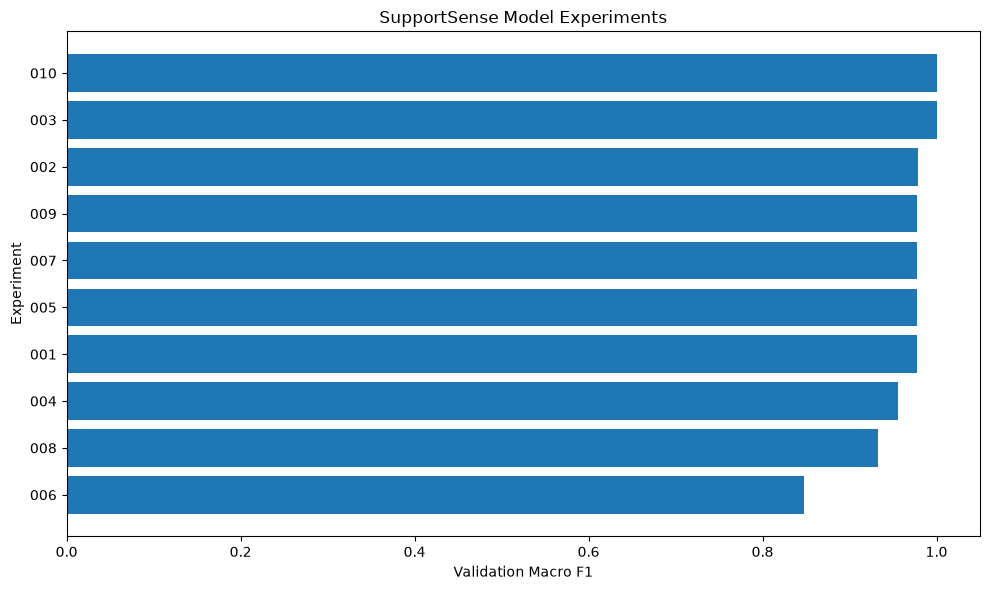

In [42]:
# Sort by validation macro F1 so the comparison is easy to read.
plot_df = experiment_results_df.sort_values("f1_macro")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["experiment_id"],
    plot_df["f1_macro"],
)

plt.xlabel("Validation Macro F1")
plt.ylabel("Experiment")
plt.title("SupportSense Model Experiments")
plt.tight_layout()
plt.show()

# Plot vocabulary size

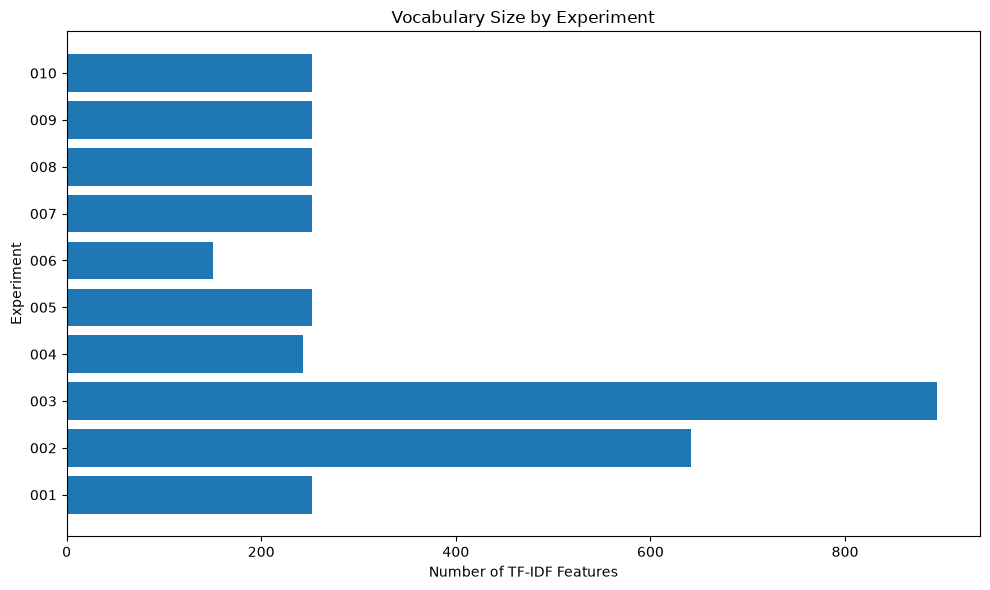

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    experiment_results_df["experiment_id"], experiment_results_df["vocabulary_size"]
)

plt.xlabel("Number of TF-IDF Features")
plt.ylabel("Experiment")
plt.title("Vocabulary Size by Experiment")
plt.tight_layout()
plt.show()

# Phase C — candidate combinations

In [44]:
experiment = {
    "experiment_id": "011",
    "notes": "Combination of experiment 003 and experiment 010",
    "ngram_range": (1, 2),
    "min_df": 1,
    "max_df": 1.0,
    "max_features": None,
    "sublinear_tf": False,
}

In [45]:
pipeline = build_text_pipeline(
    linear_svc_classifier,
    ngram_range=experiment["ngram_range"],
    min_df=experiment["min_df"],
    max_df=experiment["max_df"],
    max_features=experiment["max_features"],
    sublinear_tf=experiment["sublinear_tf"],
)

In [46]:
result = run_experiment(
    experiment_id=experiment["experiment_id"],
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

In [47]:
pd.DataFrame([result[0]])

,experiment_id,training_seconds,vocabulary_size,accuracy,precision_macro,recall_macro,f1_macro
0,011,0.01527,894,1.0,1.0,1.0,1.0


# Error Analysis on Leading Candidate

In [48]:
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_validation)

In [49]:
report_dict = classification_report(
    validation_df["category"], predictions, output_dict=True, zero_division=0
)

In [50]:
class_labels = pipeline.named_steps["classifier"].classes_

In [51]:
report_df = pd.DataFrame(report_dict).transpose().loc[class_labels]

report_df

,precision,recall,f1-score,support
account_access,1.0,1.0,1.0,8.0
billing,1.0,1.0,1.0,8.0
cancellation_refund,1.0,1.0,1.0,7.0
delivery,1.0,1.0,1.0,7.0
product_inquiry,1.0,1.0,1.0,7.0
technical_issue,1.0,1.0,1.0,8.0


In [52]:
labels = list(class_labels)

In [53]:
confusion = confusion_matrix(y_validation, predictions, labels=labels)

In [54]:
# Add category names to both axes.
confusion_df = pd.DataFrame(confusion, index=labels, columns=labels)

confusion_df

,account_access,billing,cancellation_refund,delivery,product_inquiry,technical_issue
account_access,8,0,0,0,0,0
billing,0,8,0,0,0,0
cancellation_refund,0,0,7,0,0,0
delivery,0,0,0,7,0,0
product_inquiry,0,0,0,0,7,0
technical_issue,0,0,0,0,0,8


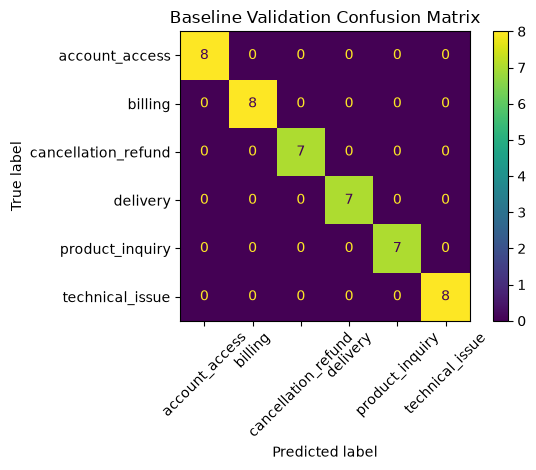

In [55]:
# Generate the visualization from predictions we already computed.
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    predictions,
    labels=labels,
    xticks_rotation=45,
)

plt.title("Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [56]:
# Return class-to-class mistakes ordered by frequency.
# confusion_pairs = extract_confusion_pairs(confusion_df)

# confusion_pairs

In [57]:
score = pipeline.decision_function(X_validation)
score.shape

(45, 6)

In [58]:
score[0]

array([-0.96016335,  0.69117774, -0.88966439, -0.9047002 , -0.97686743,
       -0.9787265 ])

In [59]:
score_confidence = score.max(axis=1)
score_confidence

array([ 0.69117774,  0.59534415,  0.45061596,  0.65622798,  0.15865908,
        0.66726621,  0.50658482,  0.43407466,  0.18887131,  0.69217557,
        0.89734457, -0.06441331,  0.57257022,  0.71159075,  0.47588668,
        0.24663746,  0.57615771,  0.62018209,  0.82647334,  0.5435178 ,
        0.91549155,  0.91813498,  0.44179131,  0.86202964,  0.63566615,
        0.52591678,  0.6382986 ,  0.498559  ,  0.72289945,  0.40918327,
        0.22818994,  0.43937824,  0.54147014,  0.11807641,  0.62187255,
        0.74455925,  0.95765767,  0.32545642,  0.75885699,  0.48613411,
        0.4352832 ,  0.69045487,  0.67241019,  0.41855669,  0.51194043])

In [60]:
score_analysis = validation_df[["ticket_id", "text", "category"]].copy()

In [61]:
score_analysis = score_analysis.rename(columns={"category": "actual_category"})

In [62]:
score_analysis["predicted_category"] = predictions

In [63]:
score_analysis["decision_score"] = score_confidence

In [64]:
score_analysis["is_correct"] = (
    score_analysis["actual_category"] == score_analysis["predicted_category"]
)

In [65]:
score_analysis.head()

,ticket_id,text,actual_category,predicted_category,decision_score,is_correct
0,TKT-1045,"Hello support, I do not recognize this charge....",billing,billing,0.691178,True
1,TKT-1089,"Hi, I forgot which email I used to sign up. I ...",account_access,account_access,0.595344,True
2,TKT-1048,"Hey team, I was billed after changing my plan....",billing,billing,0.450616,True
3,TKT-1137,"Hello support, The app crashes whenever I open...",technical_issue,technical_issue,0.656228,True
4,TKT-1209,"Hi there, Please refund my latest payment. Thi...",cancellation_refund,cancellation_refund,0.158659,True


In [66]:
# Rank candidates using the predefined primary metric.
ranked_experiments = experiment_results_df.sort_values(
    "f1_macro",
    ascending=False,
)

ranked_experiments[
    [
        "experiment_id",
        "classifier",
        "f1_macro",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "training_seconds",
        "vocabulary_size",
    ]
]

,experiment_id,classifier,f1_macro,accuracy,precision_macro,recall_macro,training_seconds,vocabulary_size
9,010,LinearSVC,1.000000,1.000000,1.000000,1.000000,0.009335,252
2,003,LogisticRegression,1.000000,1.000000,1.000000,1.000000,0.018453,894
1,002,LogisticRegression,0.979085,0.977778,0.981481,0.979167,0.014508,642
0,001,LogisticRegression,0.977778,0.977778,0.979167,0.979167,0.013132,252
6,007,LogisticRegression,0.977778,0.977778,0.979167,0.979167,0.026883,252
4,005,LogisticRegression,0.977778,0.977778,0.979167,0.979167,0.011774,252
8,009,ComplementNB,0.977778,0.977778,0.979167,0.979167,0.007997,252
3,004,LogisticRegression,0.955556,0.955556,0.958333,0.958333,0.011769,243
7,008,MultinomialNB,0.933013,0.933333,0.937500,0.934524,0.007023,252
5,006,LogisticRegression,0.847649,0.844444,0.858796,0.848214,0.010518,150
